# Configuration

In [1]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

import networkx as nx
import dill



sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2

cell_type = "K562"
unibind_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/K562/unibind/K562_UniBind_search_ayyh3bfb.tar.gz"

# Result

********** 开始读取数据...
正在读取压缩包: /home/liyang/BioWuYan/dygmamba_project/data/cell_line/K562/unibind/K562_UniBind_search_ayyh3bfb.tar.gz ...
处理完成！
共提取了 117 个 TF 的数据。
总 Region 数量: 5197171
  chrom   start     end    TF CellLine     SourceID
0  chr1  138970  138989  CTCF     K562  ENCSR000AKO
1  chr1  267998  268017  CTCF     K562  ENCSR000AKO
2  chr1  778800  778819  CTCF     K562  ENCSR000AKO
3  chr1  869917  869936  CTCF     K562  ENCSR000AKO
4  chr1  904767  904786  CTCF     K562  ENCSR000AKO
    CellLine     TF  PeakCount  Rank
112     K562    WT1     117299   1.0
83      K562   PBX2     110496   2.0
39      K562  GATA1      96140   3.0
15      K562   CTCF      73652   4.0
57      K562    MAX      73610   5.0
Top 40 AUC (Raw): 649.00
Top 40 AUC (Normalized): 0.8118

步骤 1: 过滤 Peaks (行)
  > 找到 64213 / 64213 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 850 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (64213, 850)
**************************************************
Peak-Gene: 31406, 2000, edge:198

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:436: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:451: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:505: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:524: UserWarning: set_ticklabels() s

DyGMAMBA - Precision: 0.1993, Recall: 0.2168, FPR: 0.7576, AUC: 0.2296, F-beta: 0.2026
GLUE - Precision: 0.4000, Recall: 0.0000, FPR: 0.0002, AUC: 0.4999, F-beta: 0.0002
FigR - Precision: 0.1250, Recall: 0.0000, FPR: 0.0002, AUC: 0.4999, F-beta: 0.0000
Pando - Precision: 0.1478, Recall: 0.0002, FPR: 0.0026, AUC: 0.4988, F-beta: 0.0008
CellOracle - Precision: 0.1992, Recall: 0.2170, FPR: 0.7587, AUC: 0.2291, F-beta: 0.2025
LINGER - Precision: 0.2547, Recall: 0.1962, FPR: 0.5616, AUC: 0.3173, F-beta: 0.2404
GRaNIE - Precision: 0.1683, Recall: 0.0002, FPR: 0.0023, AUC: 0.4989, F-beta: 0.0008


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:673: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='F-beta', data=result_dataframe.sort_values('F-beta', ascending=False), palette='viridis')
/tmp/ipykernel_99383/256846895.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')


--- 1. 准备 ATAC Peak 数据 ---
未提供过滤列表，将使用 atac_adata 中所有的 Peaks。
ATAC Peaks 数量: 31421
--- 2. 准备 TF ChIP 数据 ---
TF ChIP Peaks 数量: 4274788
--- 3. 计算重叠 (构建 Network) ---
构建了包含 376918 条边的 TF-Peak 网络。
--- 4. 转换为矩阵 (Matrix Construction) ---
--- 5. 封装为 AnnData ---
✅ 完成！生成的 AnnData 维度: (31421, 73) (Peaks x TFs)

步骤 1: 过滤 Peaks (行)
  > 找到 64213 / 64213 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 850 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (64213, 850)
正在解析 Consensus Peaks 坐标...
共发现 18 个共有 TF，开始评估...
正在解析 Consensus Peaks 坐标...
共发现 22 个共有 TF，开始评估...
检测到冒号格式，正在统一为连字符格式...
正在解析 Consensus Peaks 坐标...
共发现 22 个共有 TF，开始评估...
检测到冒号格式，正在统一为连字符格式...
正在解析 Consensus Peaks 坐标...
共发现 11 个共有 TF，开始评估...
格式已是连字符（chr1-100-200），无需转换。
正在解析 Consensus Peaks 坐标...
共发现 15 个共有 TF，开始评估...


...

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1519: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])


                  Peak    Gene  value_bench  label  value_method
0  chr1-999086-1001023  UBE2J2    13.624170      1      2.828991
1  chr1-999086-1001023    SDF4    14.727657      1      3.532313
2  chr1-999086-1001023  UBE2J2    15.938712      1      2.828991
3  chr1-999086-1001023  UBE2J2    23.823586      1      2.828991
4  chr1-999086-1001023  ATAD3A    11.316858      1      2.055632
计算 LINGER 的 AUPRC 时出错: Input contains infinity or a value too large for dtype('float64').


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1519: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])


                  Peak    Gene  value_bench  label  value_method
0  chr1-999086-1001023  UBE2J2    13.624170      1           0.0
1  chr1-999086-1001023    SDF4    14.727657      1           0.0
2  chr1-999086-1001023  UBE2J2    15.938712      1           0.0
3  chr1-999086-1001023  UBE2J2    23.823586      1           0.0
4  chr1-999086-1001023  ATAD3A    11.316858      1           0.0


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1430: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


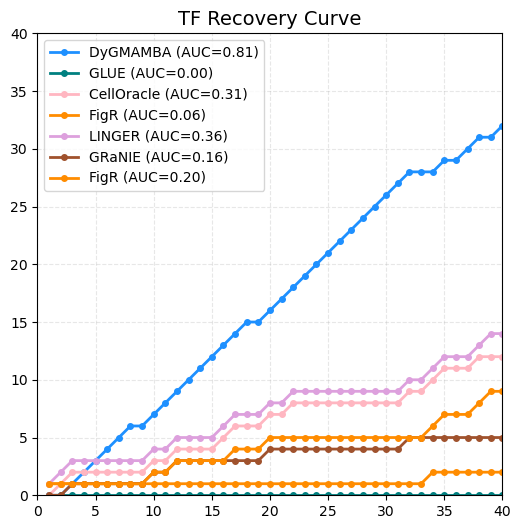

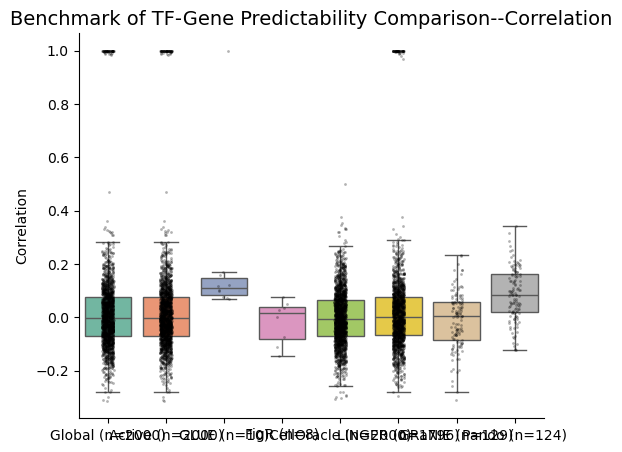

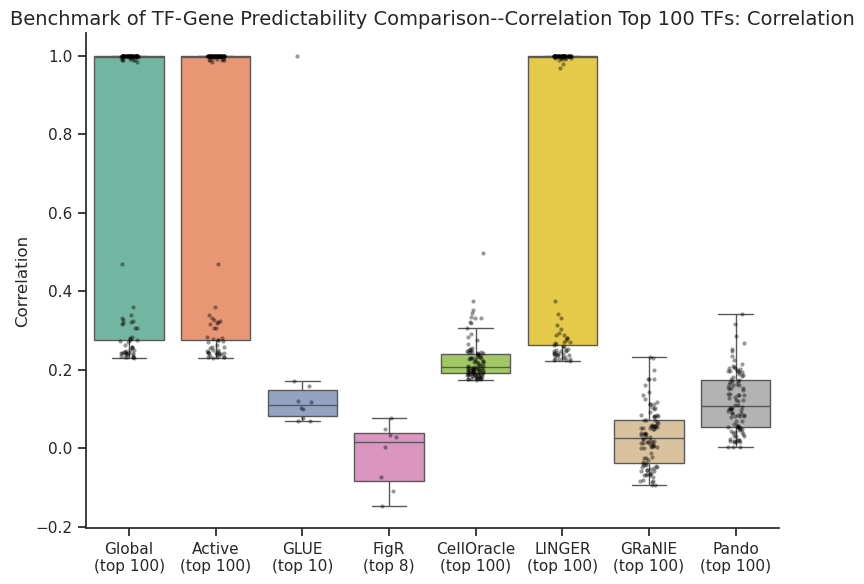

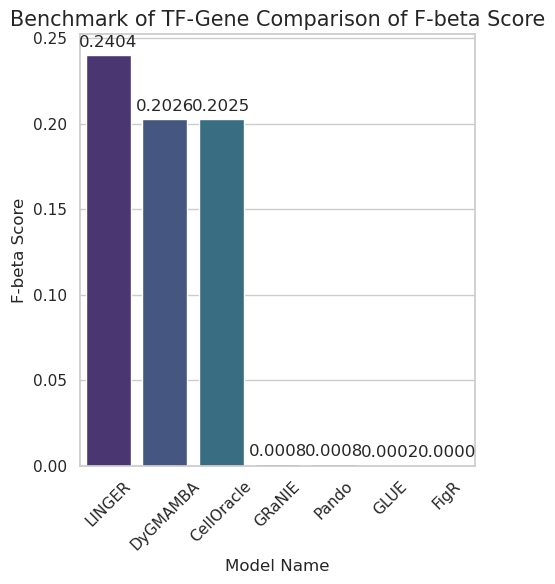

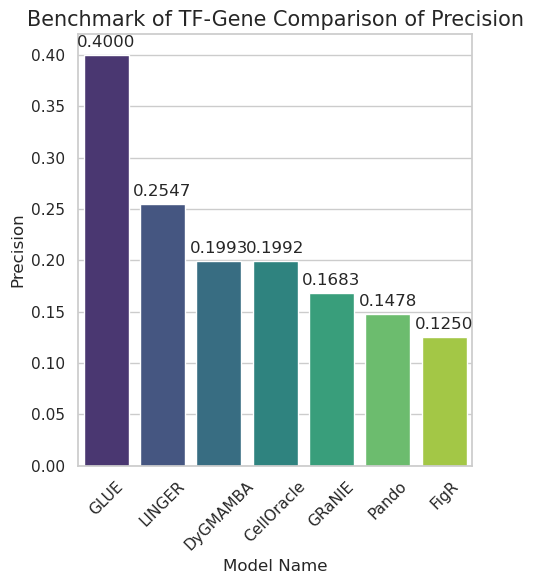

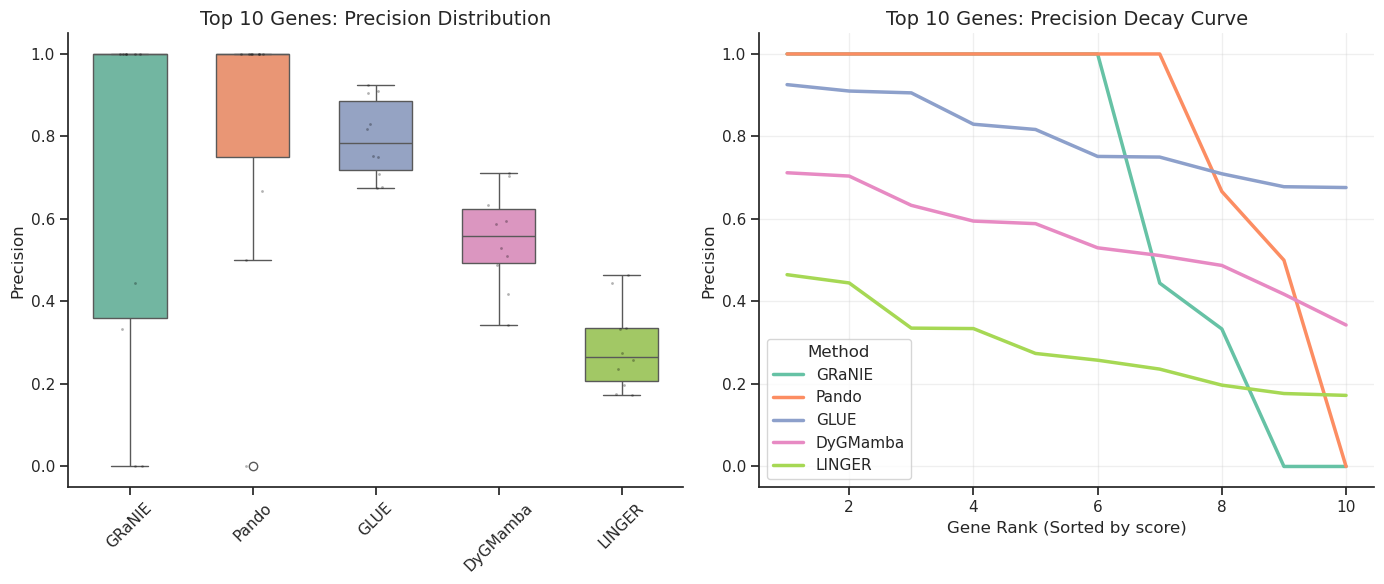

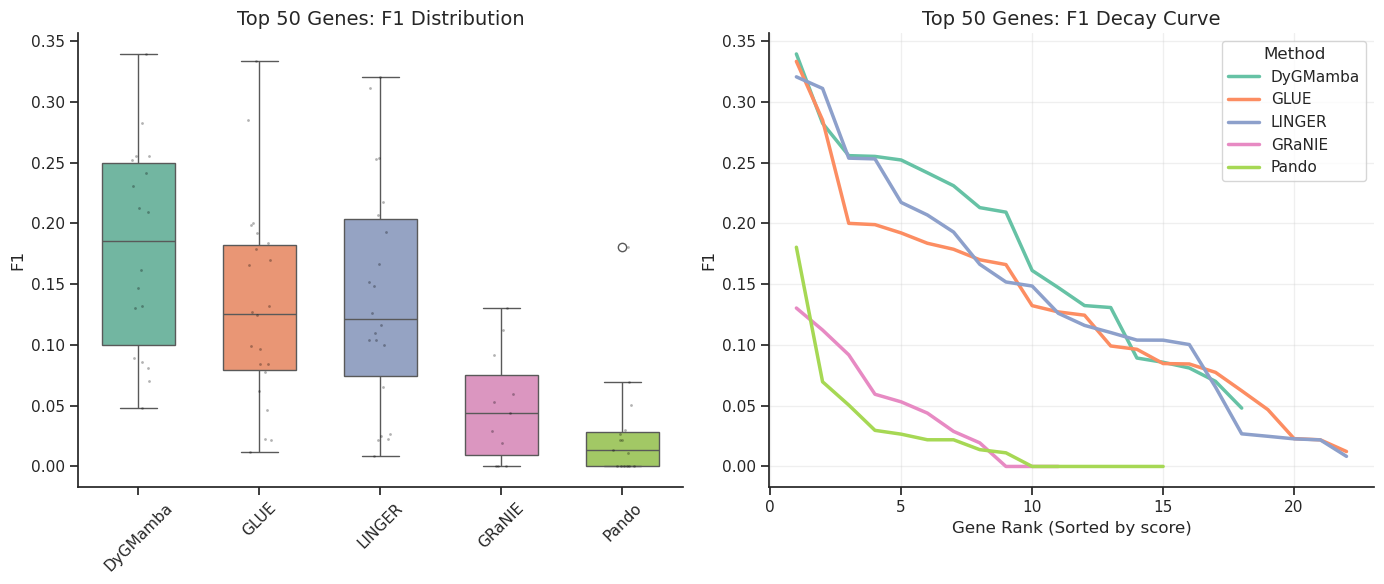

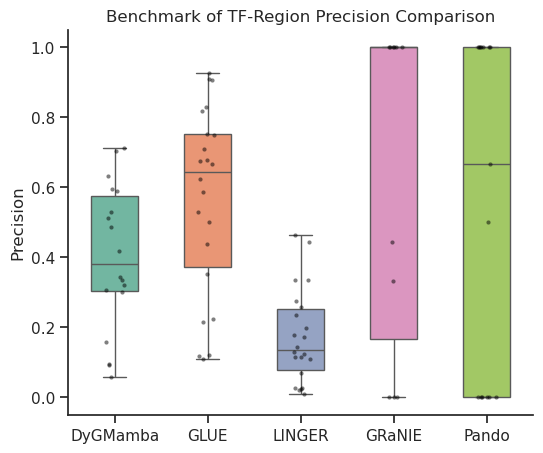

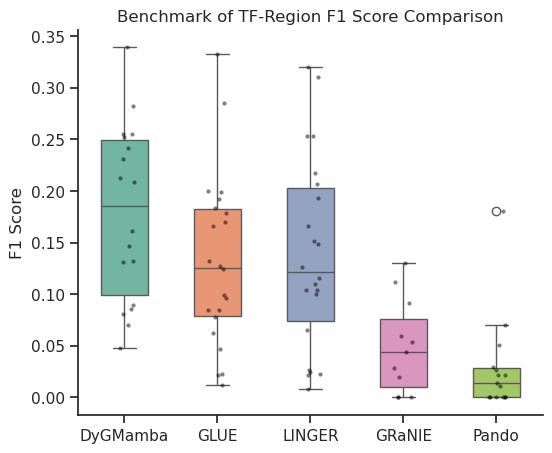

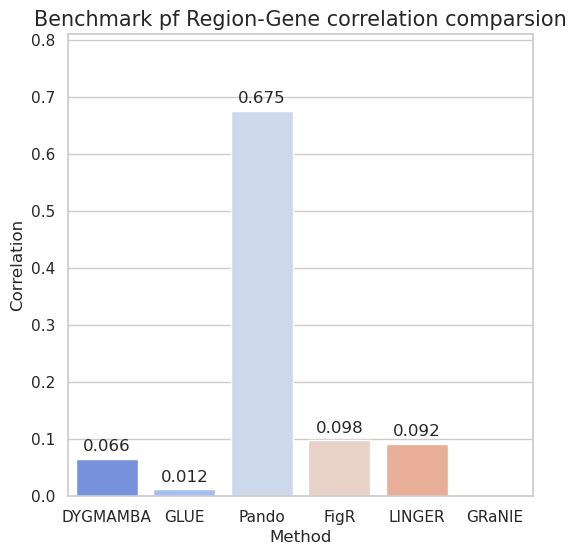

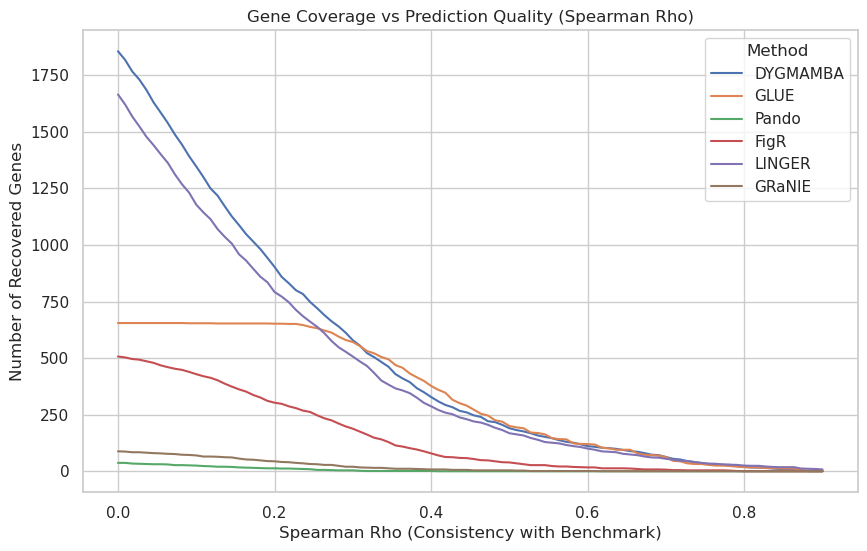

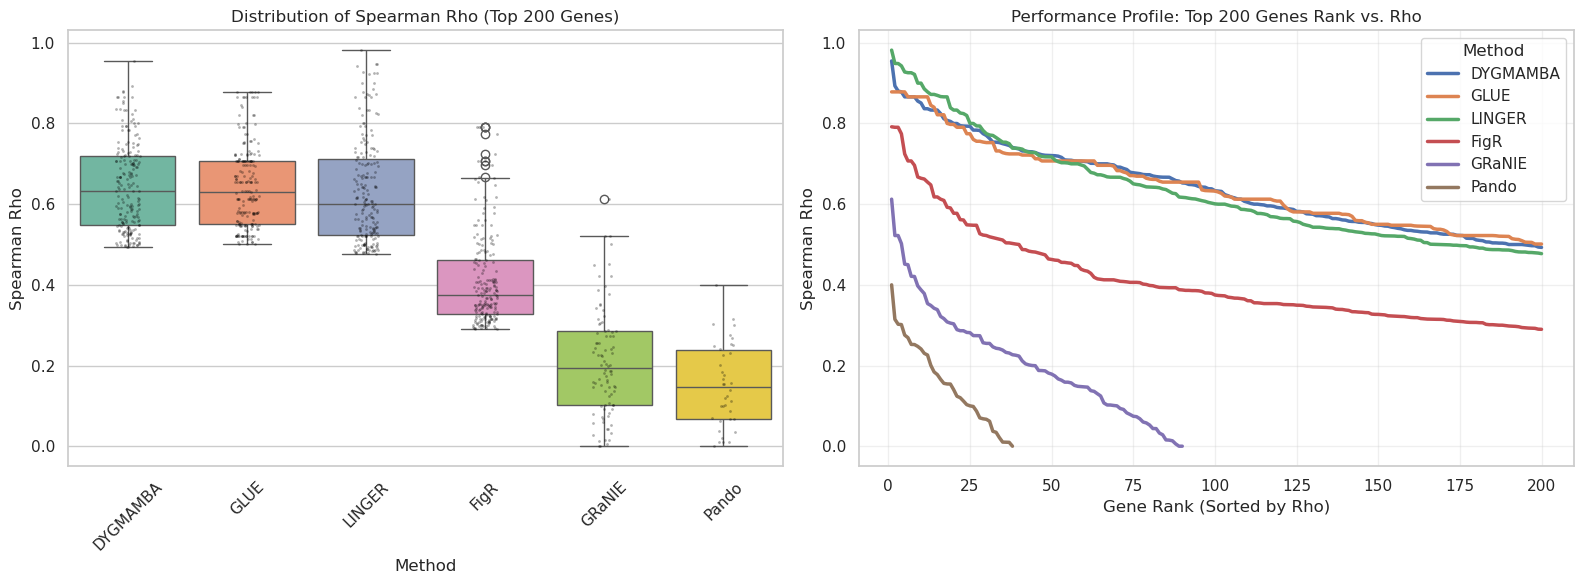

In [2]:
from pdata.data_read import read_unibind_file

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/"

output_path = data_path + "benchmark/"

os.makedirs(output_path, exist_ok=True )

unibind_df_file = data_path + "benchmark/unibind_df.pkl"

model_result_path = data_path + "data_dyg/"

method_list = ["DyGMamba", "CellOracle", "FigR", "GLUE", "LINGER", "GRaNIE", "Pando"]

#############################################################################
#
# Unibind data processing
#
#############################################################################

unibind_df, count_region_df = read_unibind_file(unibind_file)

unibind_df["CellLine"] = unibind_df["CellLine"].str.split('_').str[0]
count_region_df["CellLine"] = count_region_df["CellLine"].str.split('_').str[0]

print(unibind_df.head())
print(count_region_df.head())

unibind_df.to_pickle(output_path + "unibind_df.pkl")
count_region_df.to_pickle(output_path + "count_region_df.pkl")


##############################################################################
#
# TF recovery
#
##############################################################################
from benchmark.benchmark_model import analysis_tf_recovery

analysis_tf_recovery(data_path, output_path, method_list)

##############################################################################
#
# TF-Gene
#
##############################################################################

from benchmark.benchmark_model import analysis_tf_gene_data, analysis_tf_gene_all_correlation, \
    plot_top_n_tf_comparison, dyg_tf_gene_result
    
from benchmark.benchmark_model import analysis_tf_gene_all_precision


tf_gene_grn, avg_active_tf_gene_grn, avg_global_tf_gene_grn = dyg_tf_gene_result(data_path, model_result_path)

result_dict = analysis_tf_gene_data( data_path, method_list )

analysis_tf_gene_all_correlation(output_path, result_dict)

###########################
# Top 100 correlation

# 1. 定义绘图顺序
my_order = ['Global', 'Active', 'GLUE', 'FigR', 'CellOracle', 'LINGER', 'GRaNIE', 'Pando']

plot_top_n_tf_comparison(result_dict, output_path, top_n=100, score_col='Correlation', my_order=my_order)

#############################
# Total correlation

result_dataframe = analysis_tf_gene_all_precision(data_path, output_path, method_list)

############################
# figure plot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 6))

ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')

plt.title('Benchmark of TF-Gene Comparison of Precision', fontsize=15)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xticks(rotation=45) 

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig(output_path + 'Benchmark of TF-Gene Comparison of Precision.png', dpi=1200, bbox_inches='tight')

##############################################################################
#
# TF-Region
#
##############################################################################


from benchmark.benchmark_model import analysis_tf_region
###################################
# Benchmark

f_score = 0.1

tf_region_result = analysis_tf_region(unibind_df_file, data_path, f_score, method_list)


###################################
# 
from benchmark.benchmark_model import plot_top_n_comparison

# # 1. 准备数据字典
# tf_region_result = {
#     "DYGMAMBA": dyg_results,
#     "GLUE": glue_results,
#     "LINGER": linger_results,
#     "GRaNIE": granie_results,
#     "Pando": pando_results
# }

# 2. 调用函数
# 例如：对比前 10 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict=tf_region_result, 
    output_file=output_path + 'Benchmark of TF-Region Comparison of Top 10 Precision.png',
    top_n=10, 
    score_col="Precision"
)

# 2. 调用函数
# 例如：对比前 50 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict= tf_region_result, 
    output_file= output_path + 'Benchmark of TF-Region Comparison of Top 50 F1 Score.png',
    top_n= 50, 
    score_col= "F1"
)


###########################
# Boxplot
###########################
# precisioin

analysis_type = "Precision"
tf_region_df = []

for method_name, df in tf_region_result.items():

    tf_region_df.append(df[[analysis_type, 'Method']])

tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

# ==========================
# @ 绘制箱形图
# ==========================
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

ax = sns.boxplot(data=tf_region_df_combined, 
                x='Method',    # x轴放分组标签
                y=analysis_type,        # y轴放数值
                palette="Set2", # 配色方案
                width=0.5)     # 箱子宽度

sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
            color='black', size=3, alpha=0.5, jitter=True)

plt.title("Benchmark of TF-Region Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

plt.savefig(output_path + 'Benchmark of TF-Region Comparison of Precision.png', dpi=1200, bbox_inches='tight')


################################
# F1 score

analysis_type = "F1"
tf_region_df = []

for method_name, df in tf_region_result.items():

    tf_region_df.append(df[[analysis_type, 'Method']])

tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

# =============================
# @ 绘制箱形图
# =============================
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

ax = sns.boxplot(data=tf_region_df_combined, 
                x='Method',    # x轴放分组标签
                y=analysis_type,        # y轴放数值
                palette="Set2", # 配色方案
                width=0.5)     # 箱子宽度

sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
            color='black', size=3, alpha=0.5, jitter=True)

plt.title("Benchmark of TF-Region F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

plt.savefig(output_path + 'Benchmark of TF-Region Comparison of F1 Score.png', dpi=1200, bbox_inches='tight')

##############################################################################
#
# Region-Gene
#
##############################################################################

from benchmark.benchmark_model import analysis_region_gene, evaluate_r2g_benchmark, \
    plot_recovery_curves, plot_top_n_methods_comparison

results, method_data, benchmark_peak_gene_df = analysis_region_gene(data_path, output_path, method_list)

#################################
# Correlation

plot_data = results.T.reset_index()
plot_data.columns = ['Method', 'Correlation']

# 2. 绘图
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid") # 设置清爽的白色网格背景

ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("Benchmark pf Region-Gene correlation comparsion", fontsize=15)
plt.ylim(0, max(plot_data['Correlation']) * 1.2) # 给上方数值留点空间

plt.savefig(output_path + 'Benchmark of Region-Gene Correlation Comparison.png', dpi=1200, bbox_inches='tight')


#############################
# score analysis

corr_df, metrics_df = evaluate_r2g_benchmark(benchmark_peak_gene_df, method_data)

corr_df['Abs_Spearman_Rho'] = corr_df['Spearman_Rho'].abs()

# 调用
plot_recovery_curves(corr_df, 
                    output_file=output_path + 'Benchmark of Recovery Curve of Region-Gene Prediction.png',
                    compared_method='Abs_Spearman_Rho')

plot_top_n_methods_comparison(corr_df, 
                            output_file=output_path + 'Benchmark of Region-Gene Comparison of Top 200 Spearman Rho.png',
                            top_n=200, compare_method='Abs_Spearman_Rho')


[TF-Gene per-TF] DyGMamba: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] GLUE: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] FigR: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] CellOracle: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] LINGER: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] GRaNIE: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] Pando: median Precision=0.0000, median F1.0=0.0000, n_TF=73


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1516: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  if len(group) < min_links:


✓ 已保存：TF-Gene Per-TF Precision Boxplot


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1537: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  'Common_Links': len(merged)


✓ 已保存：TF-Gene Per-TF F1 Boxplot

[TF-Gene Correlation Summary]
    Method  Median_Corr  Mean_Corr  Std_Corr  N_TF
      GLUE     0.110134   0.198741  0.283608    10
     Pando     0.084420   0.085966  0.098440   124
      FigR     0.015763  -0.017029  0.081836     8
    GRaNIE     0.003786  -0.012163  0.104885   129
    LINGER     0.002573   0.034096  0.204461  1796
    Global    -0.004036   0.028942  0.196750  2000
    Active    -0.004036   0.028942  0.196750  2000
CellOracle    -0.006165  -0.000855  0.101933  2000


...

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

✓ 已保存：TF-Region Overall Precision and F1
✓ 已保存：TF-Region Macro Precision vs F Score
[Region-Gene] DYGMAMBA: Prec=1.0000  Rec=0.8980  F1=0.6198  AUPRC=1.0000  TP=46182  FP=0  FN=5244
[Region-Gene] GLUE: Prec=1.0000  Rec=0.0240  F1=0.0237  AUPRC=1.0000  TP=1234  FP=0  FN=50192
[Region-Gene] Pando: Prec=1.0000  Rec=0.0012  F1=0.0012  AUPRC=1.0000  TP=64  FP=0  FN=51362
[Region-Gene] FigR: Prec=1.0000  Rec=0.0197  F1=0.0195  AUPRC=1.0000  TP=1015  FP=0  FN=50411
  [警告] LINGER AUPRC 计算失败：Input contains infinity or a value too large for dtype('float64').
[Region-Gene] LINGER: Prec=1.0000  Rec=0.8214  F1=0.5823  AUPRC=nan  TP=42241  FP=0  FN=9185
[Region-Gene] GRaNIE: Prec=1.0000  Rec=0.0029  F1=0.0029  AUPRC=1.0000  TP=147  FP=0  FN=51279


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1836: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1836: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1836: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1836: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

✓ 已保存：Region-Gene Precision Recall F1 AUPRC
✓ 已保存：Region-Gene PR Curve
✓ 已保存：Region-Gene Precision vs F1


,Method,Precision,Recall,F_score,AUPRC,TP,FP,FN,N_pred,N_true
0,DYGMAMBA,1.0,0.898028,0.619751,1.0,46182,0,5244,46182,51426
1,GLUE,1.0,0.023996,0.023711,1.0,1234,0,50192,1234,51426
2,Pando,1.0,0.001245,0.001244,1.0,64,0,51362,64,51426
3,FigR,1.0,0.019737,0.019544,1.0,1015,0,50411,1015,51426
4,LINGER,1.0,0.821394,0.582261,NaN,42241,0,9185,42241,51426
5,GRaNIE,1.0,0.002858,0.002854,1.0,147,0,51279,147,51426


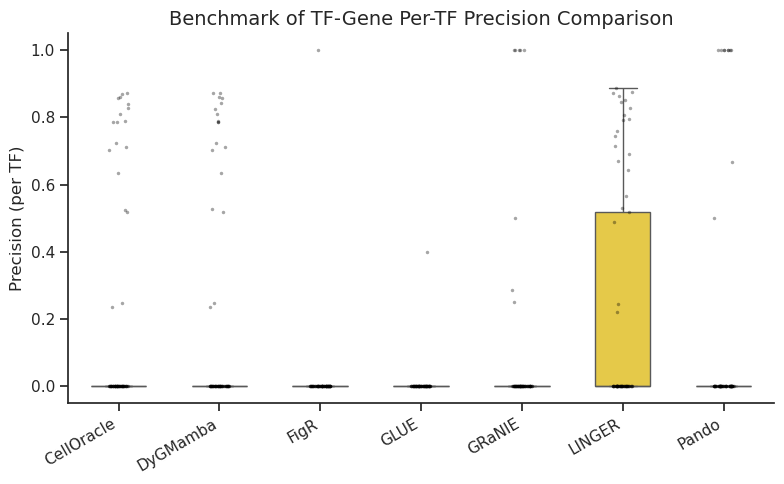

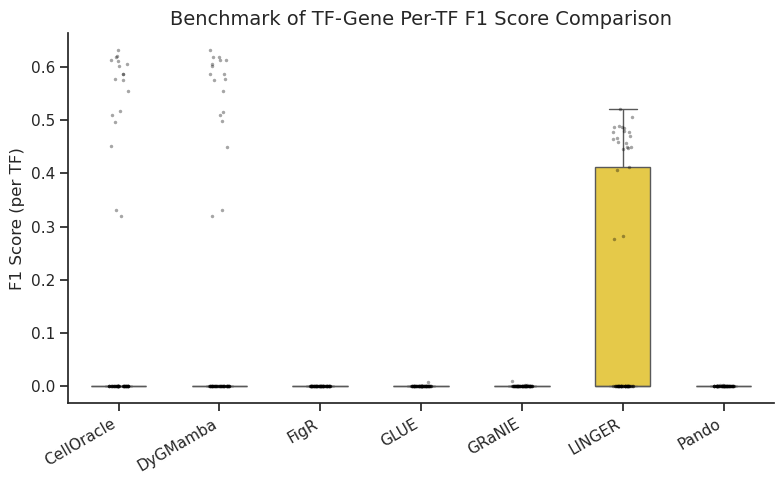

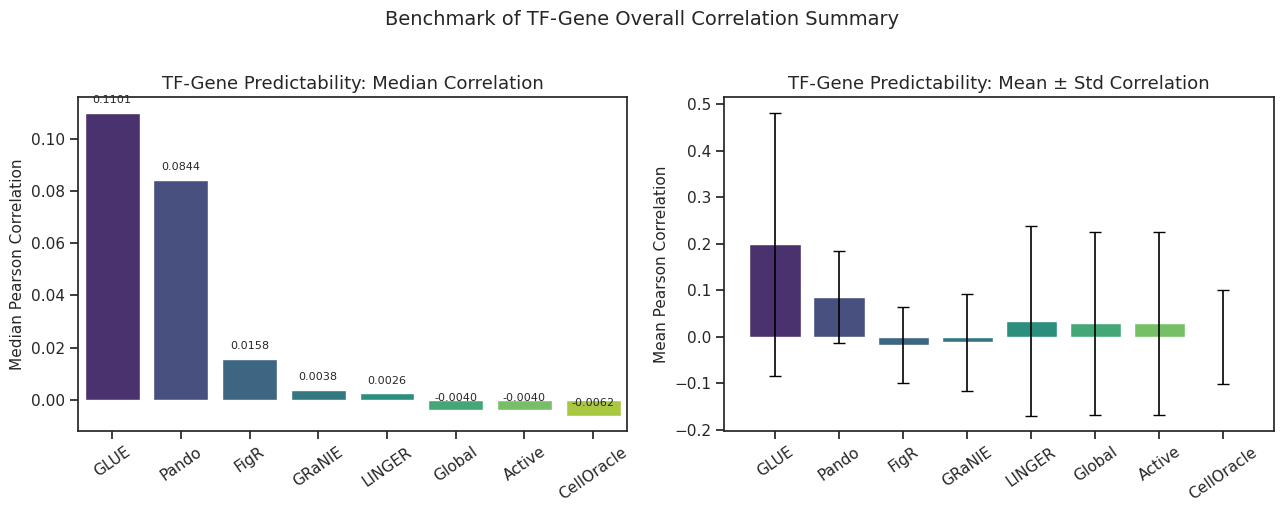

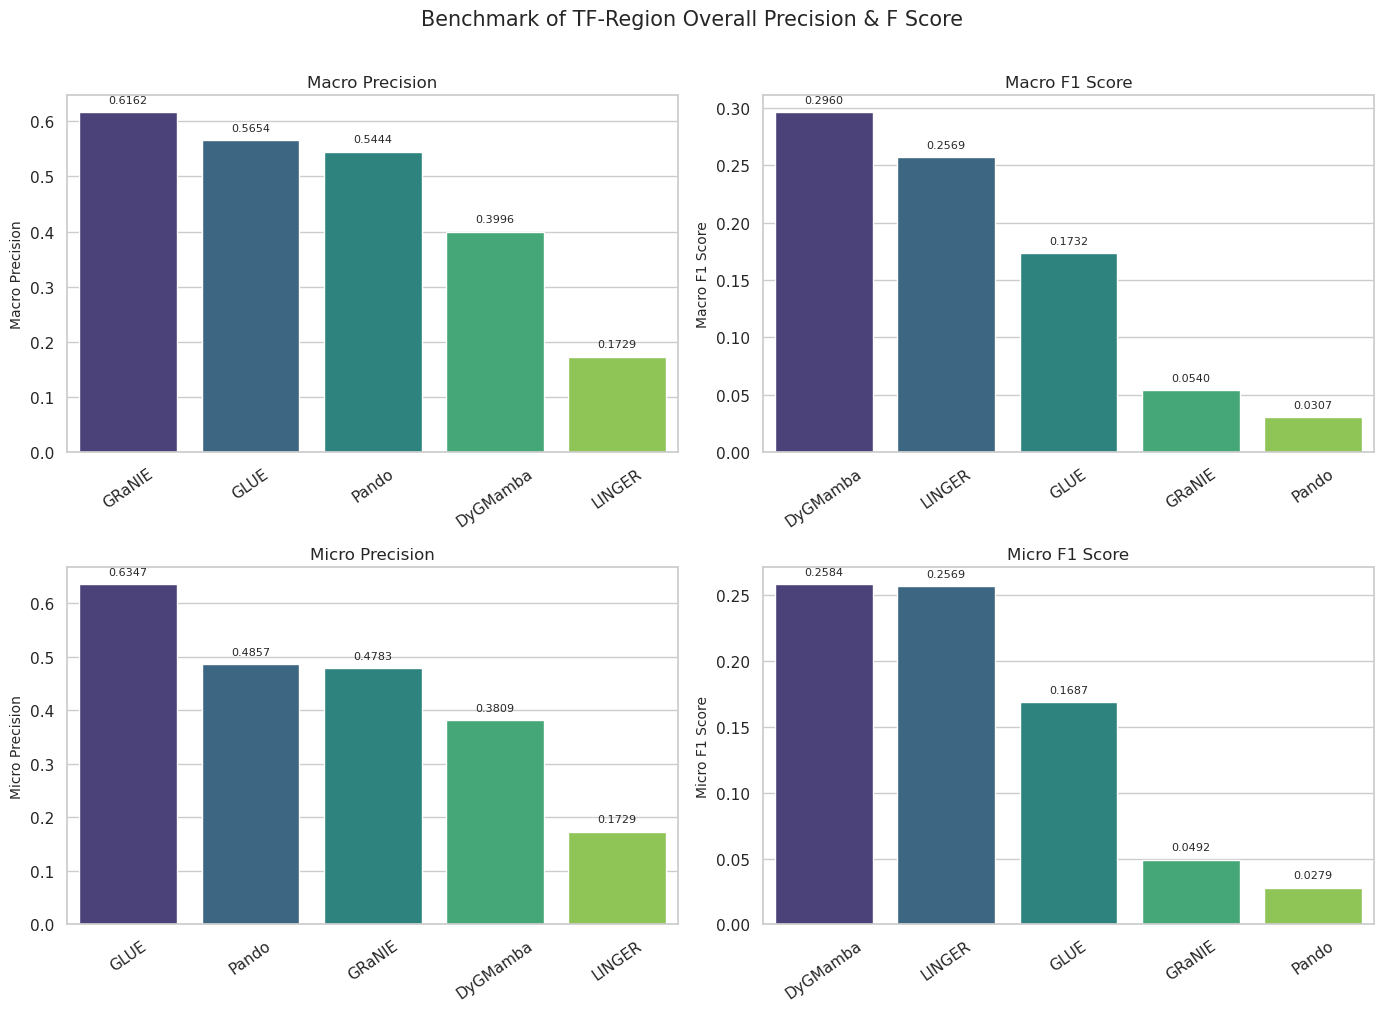

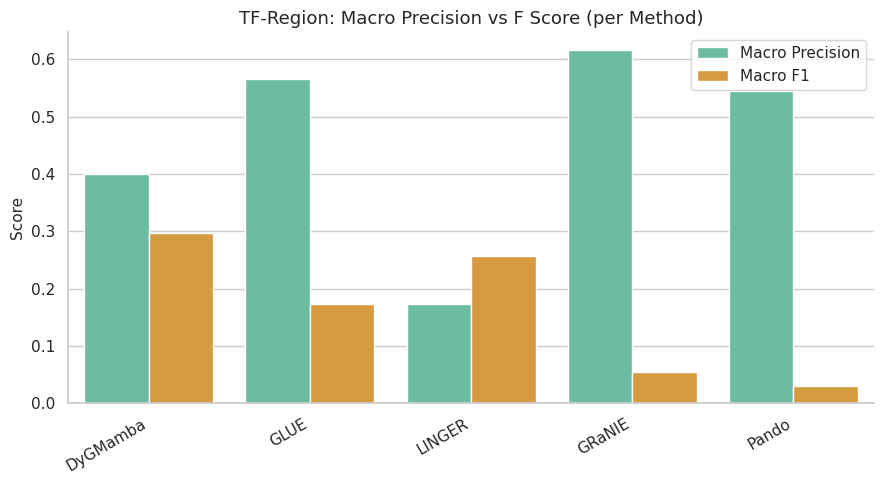

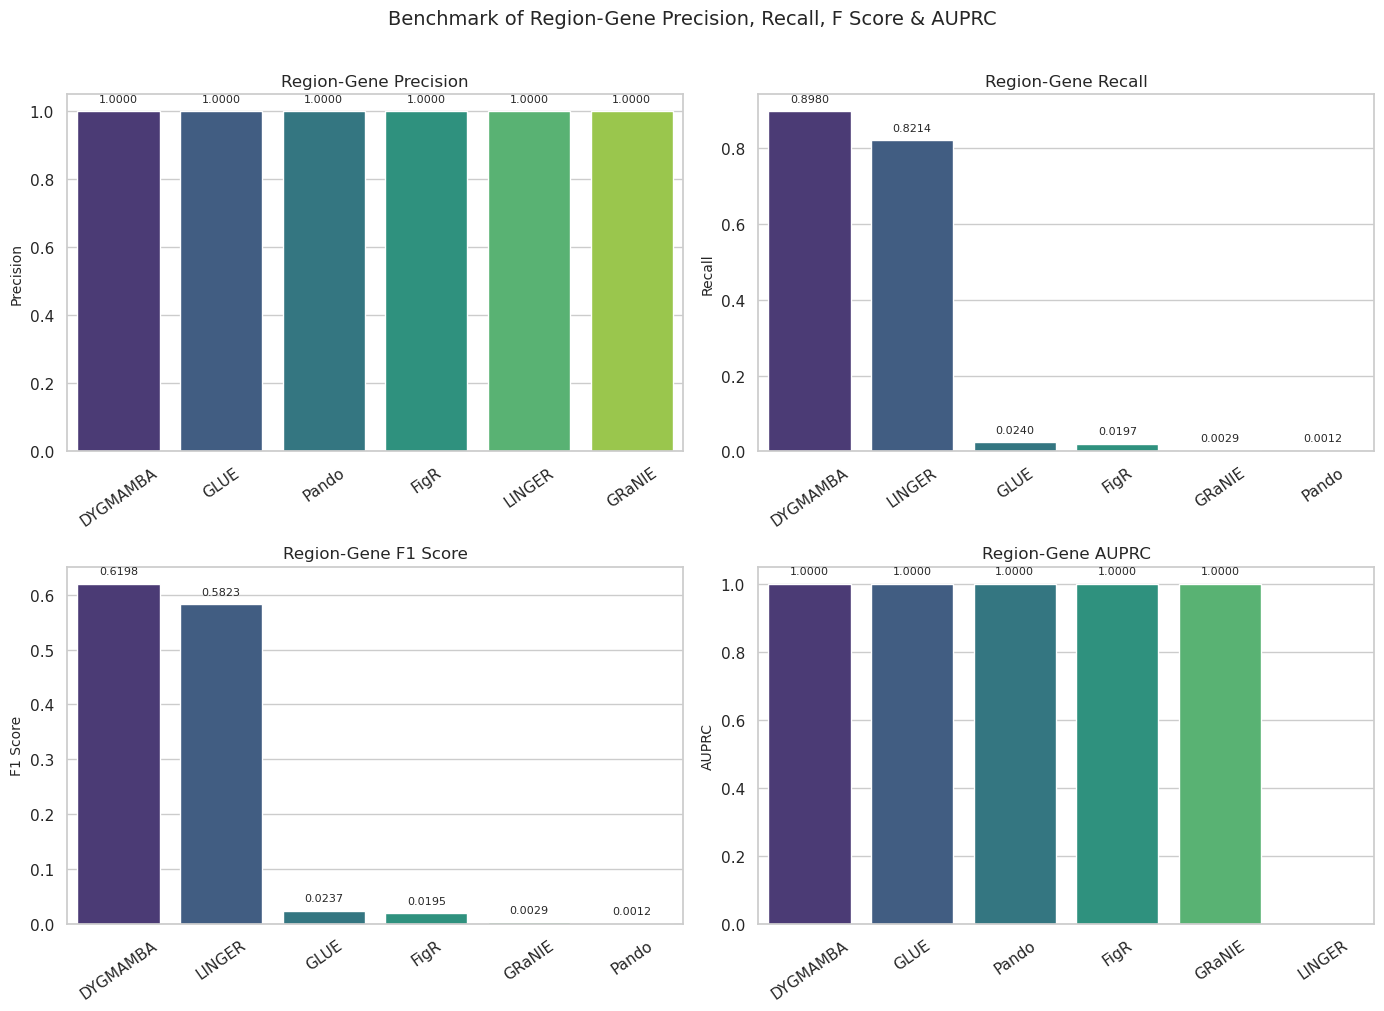

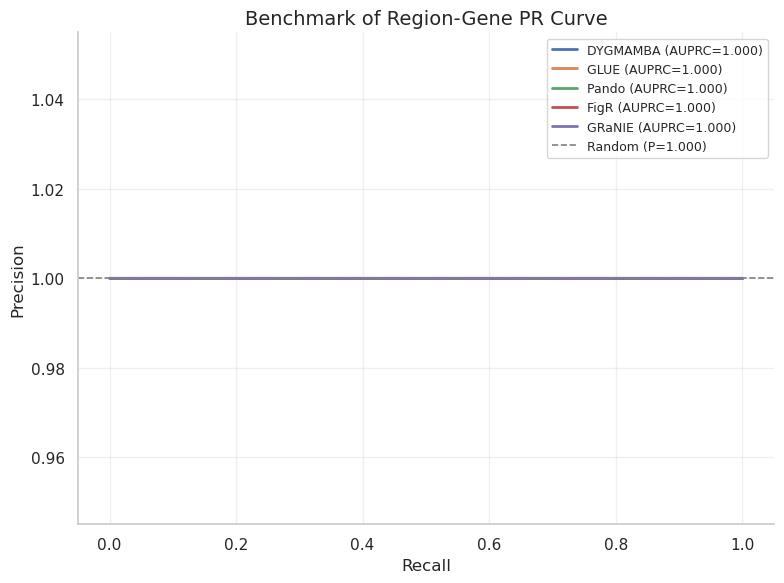

In [7]:
from benchmark.benchmark_model import analysis_tf_gene_per_tf_precision, \
    analysis_tf_gene_correlation_summary, \
    analysis_tf_region_overall, \
    analysis_region_gene_precision

analysis_tf_gene_per_tf_precision(data_path, output_path, method_list, beta=1.0)

# 补充分析 2（直接复用已有 result_dict）
analysis_tf_gene_correlation_summary(result_dict, output_path)

# 补充分析 3（直接复用已有 tf_region_result）
analysis_tf_region_overall(tf_region_result, output_path, beta=1.0)

# 补充分析 4（直接复用已有 method_data 和 benchmark_peak_gene_df）
analysis_region_gene_precision(benchmark_peak_gene_df, method_data, output_path, beta=1.0)

[Per-TF] DyGMamba     | n_TF=  73 | median Prec=0.0000 | median F1=0.0000
[Per-TF] GLUE         | n_TF=  73 | median Prec=0.0000 | median F1=0.0000
[Per-TF] FigR         | n_TF=  73 | median Prec=0.0000 | median F1=0.0000
[Per-TF] CellOracle   | n_TF=  73 | median Prec=0.0000 | median F1=0.0000
[Per-TF] LINGER       | n_TF=  73 | median Prec=0.0000 | median F1=0.0000
[Per-TF] GRaNIE       | n_TF=  73 | median Prec=0.0000 | median F1=0.0000
[Per-TF] Pando        | n_TF=  73 | median Prec=0.0000 | median F1=0.0000

── 正在绘制 Precision 的 Top N 系列图 ──


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1996: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:2017: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


  ✓ 已保存：Benchmark of TF-Gene Per-TF Precision Top20 Precision.png


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1996: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:2017: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


  ✓ 已保存：Benchmark of TF-Gene Per-TF Precision Top50 Precision.png


...

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1996: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:2017: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


  ✓ 已保存：Benchmark of TF-Gene Per-TF Precision Top50.png


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1996: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:2017: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


  ✓ 已保存：Benchmark of TF-Gene Per-TF F_score Top50.png


,Method,F_score,Rank,TF
0,DyGMamba,0.630807,1,PKNOX1
1,DyGMamba,0.618983,2,JUN
2,DyGMamba,0.617692,3,NR2C2
3,DyGMamba,0.612109,4,GATA2
4,DyGMamba,0.611783,5,E2F6
...,...,...,...,...
345,Pando,0.000000,46,E2F1
346,Pando,0.000000,47,YY1
347,Pando,0.000000,48,CTCFL
348,Pando,0.000000,49,CTCF


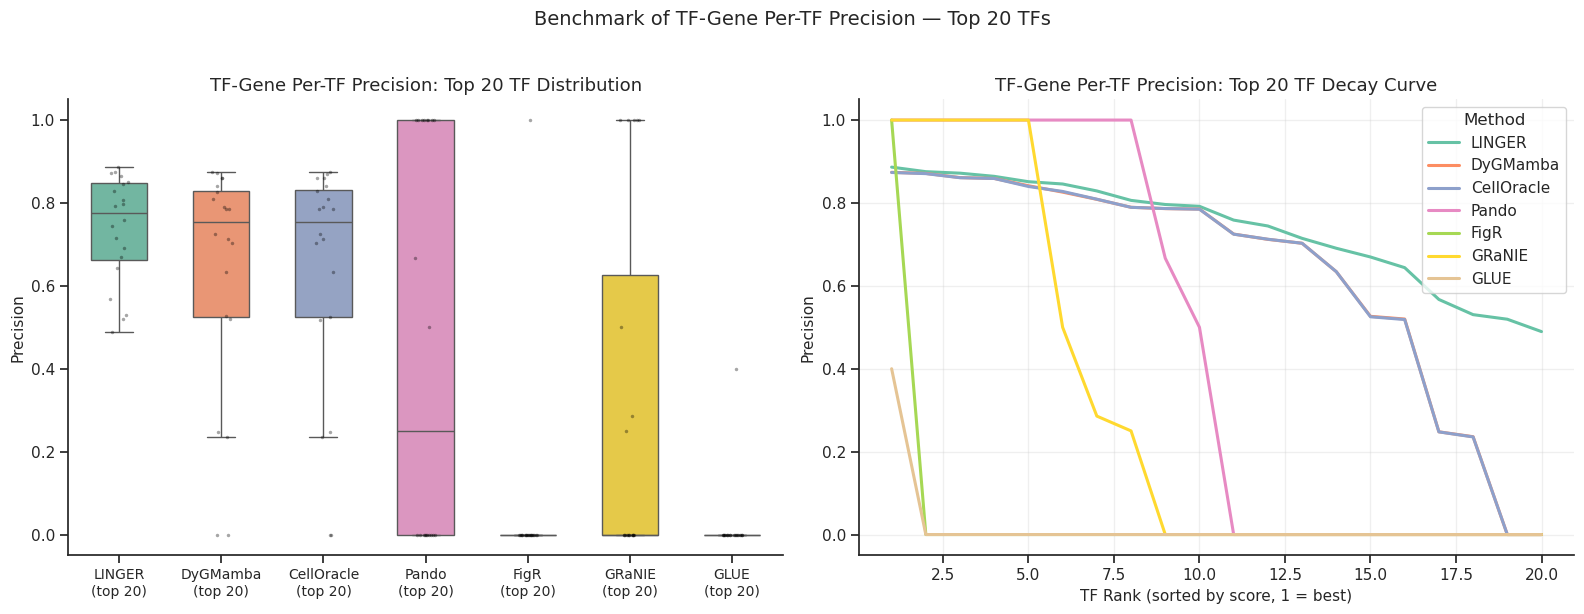

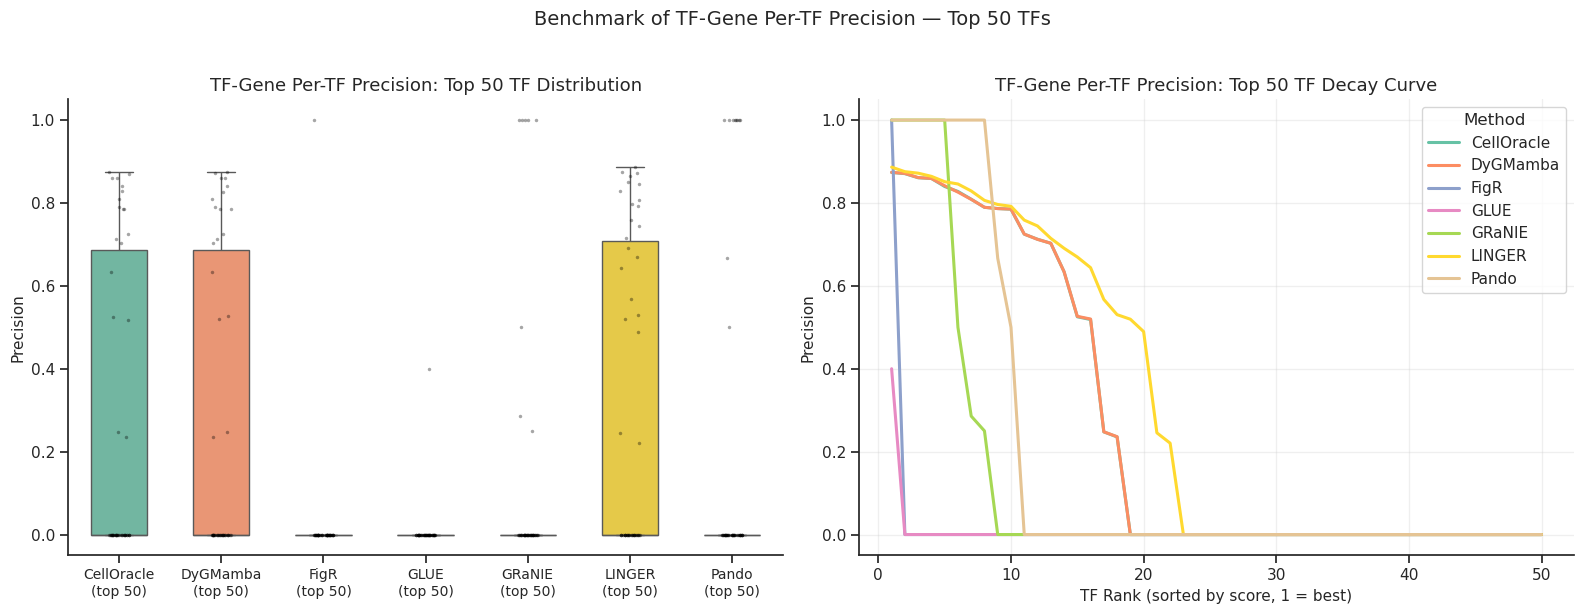

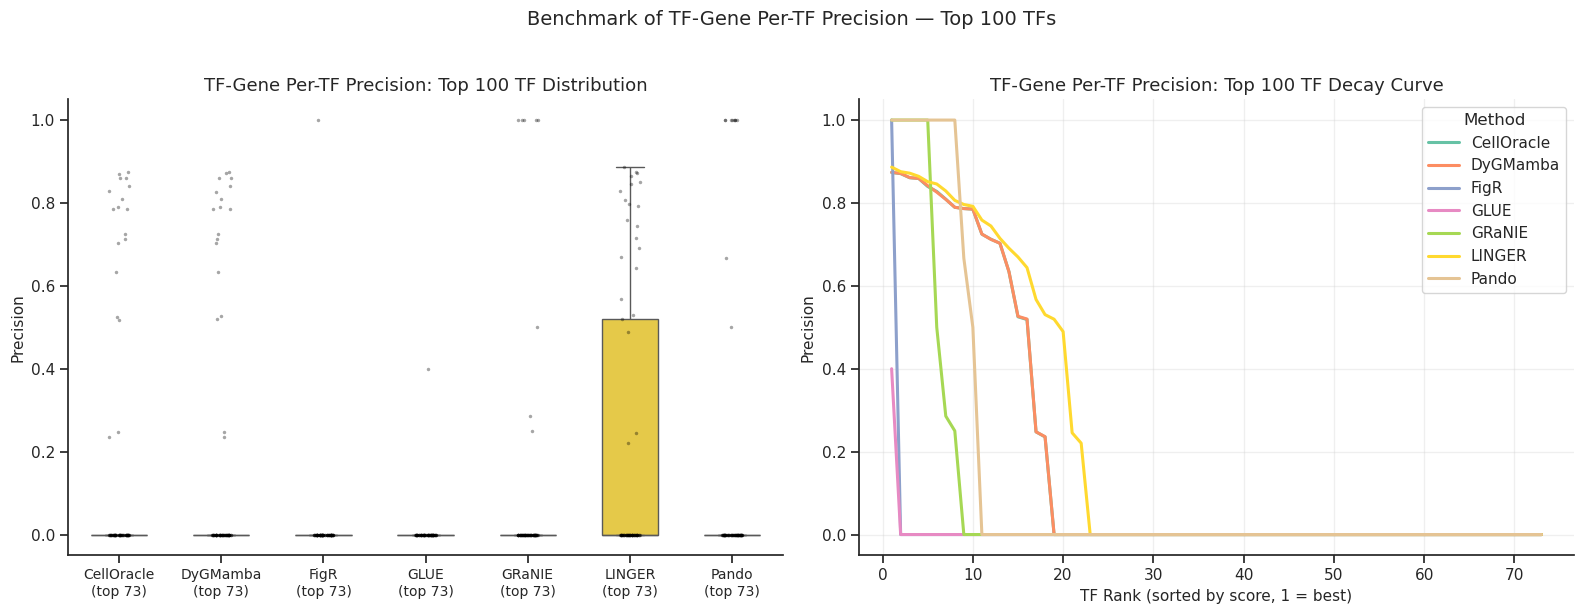

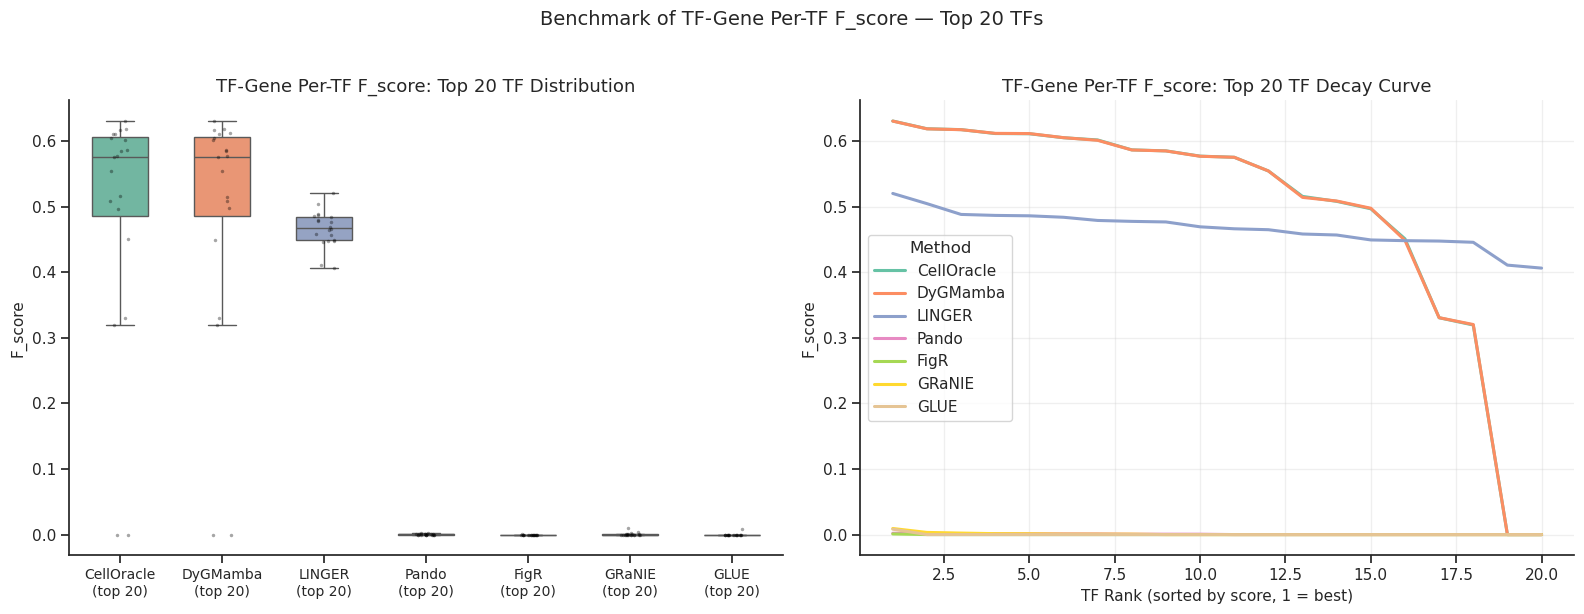

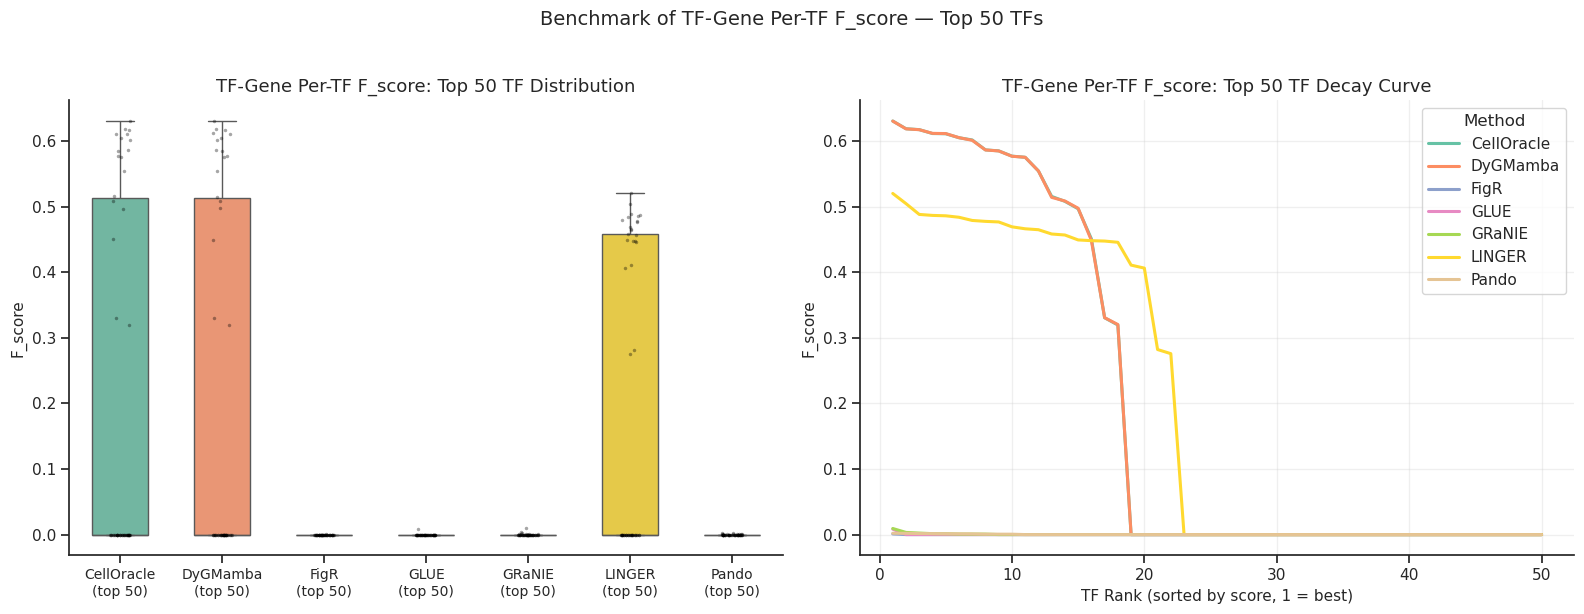

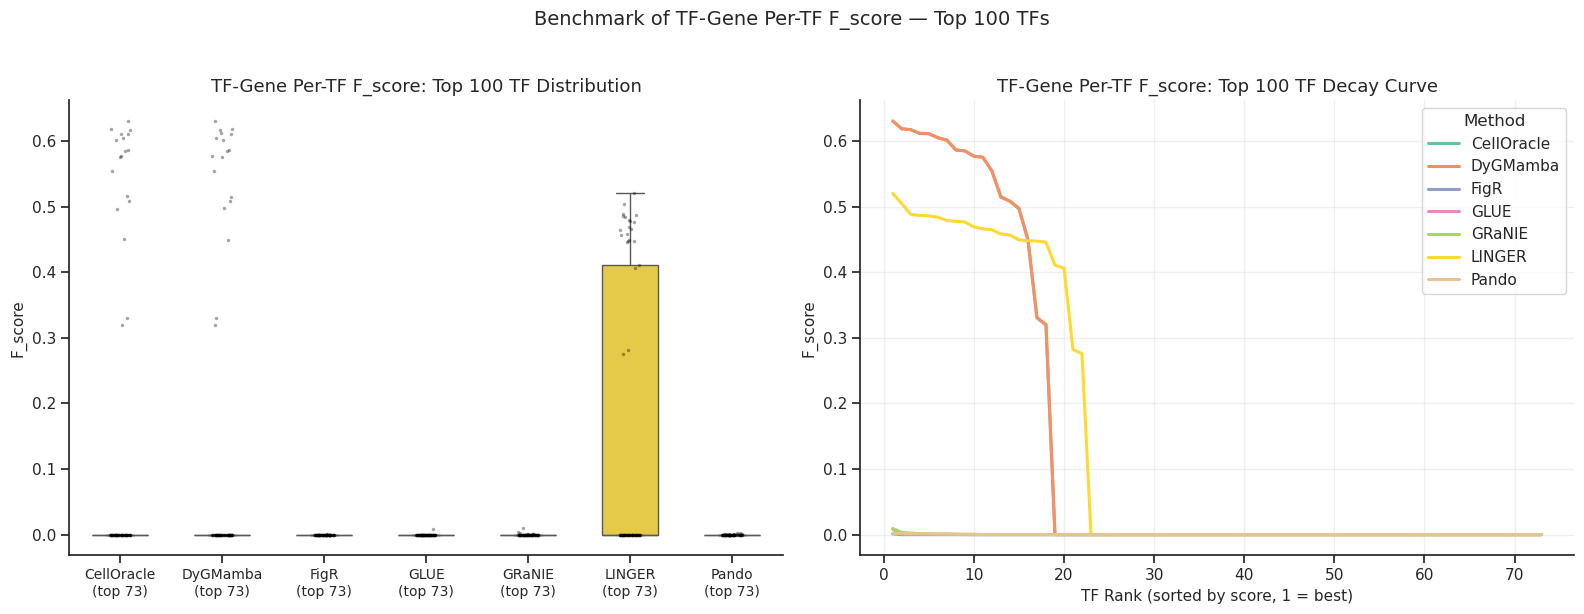

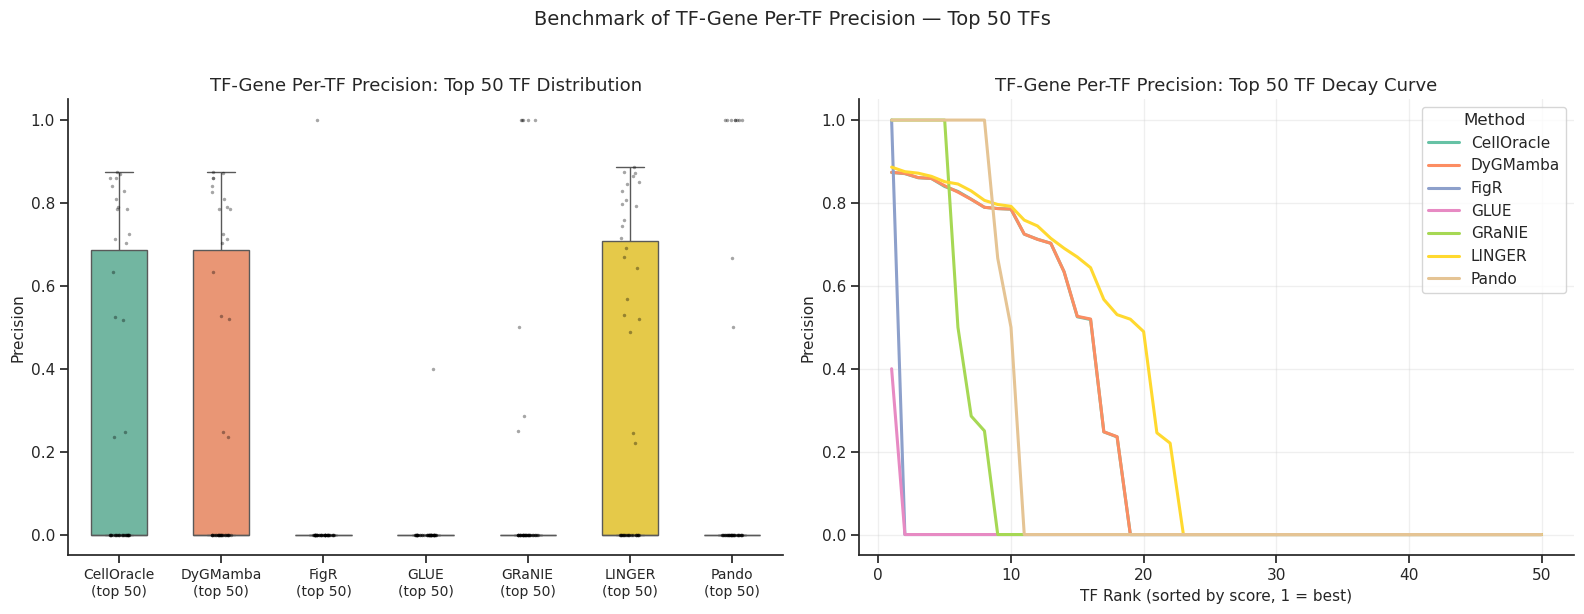

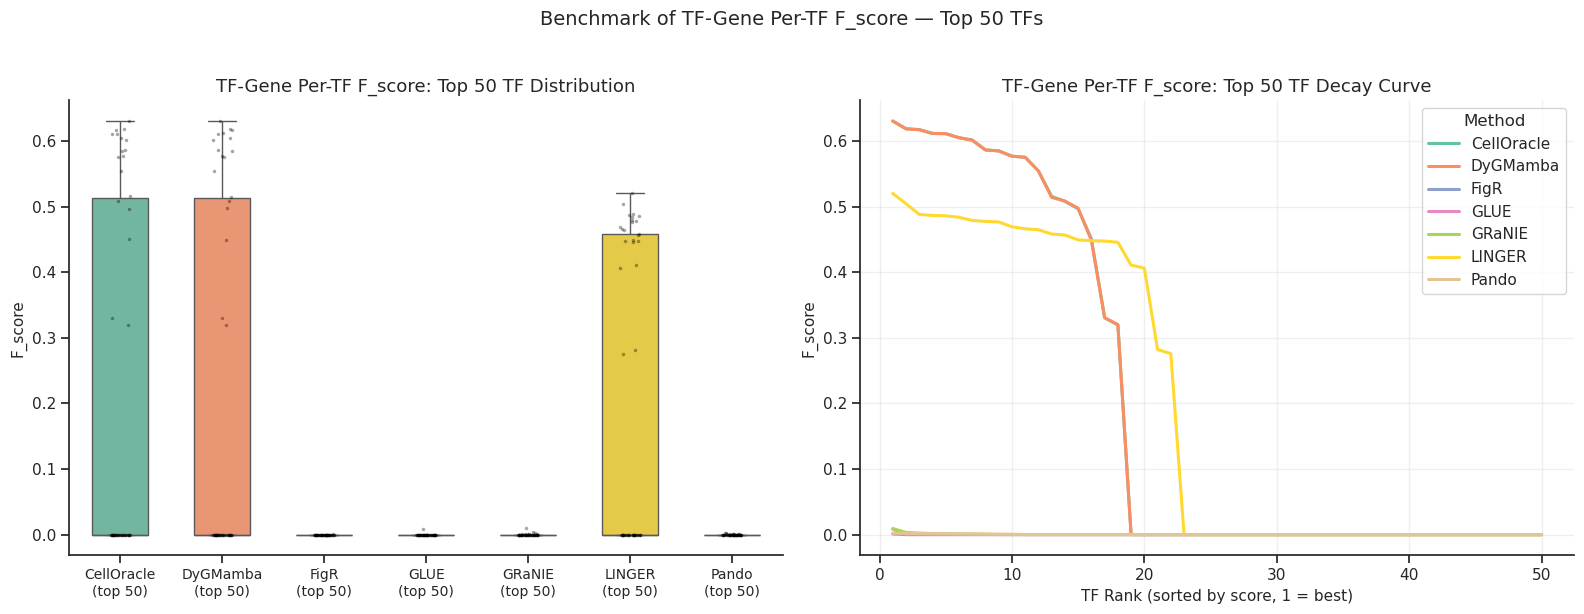

In [8]:
from benchmark.benchmark_model import plot_top_n_per_tf_comparison
from benchmark.benchmark_model import analysis_tf_gene_per_tf_topn

per_tf_dict = analysis_tf_gene_per_tf_topn(
    data_path   = data_path,
    output_path = output_path,
    method_list = method_list,
    top_n_list  = [20, 50, 100],
    beta        = 1.0,
)
plot_top_n_per_tf_comparison(per_tf_dict, output_path, top_n=50, score_col="Precision")
plot_top_n_per_tf_comparison(per_tf_dict, output_path, top_n=50, score_col="F_score")